# PSET 5

1) implied volatility

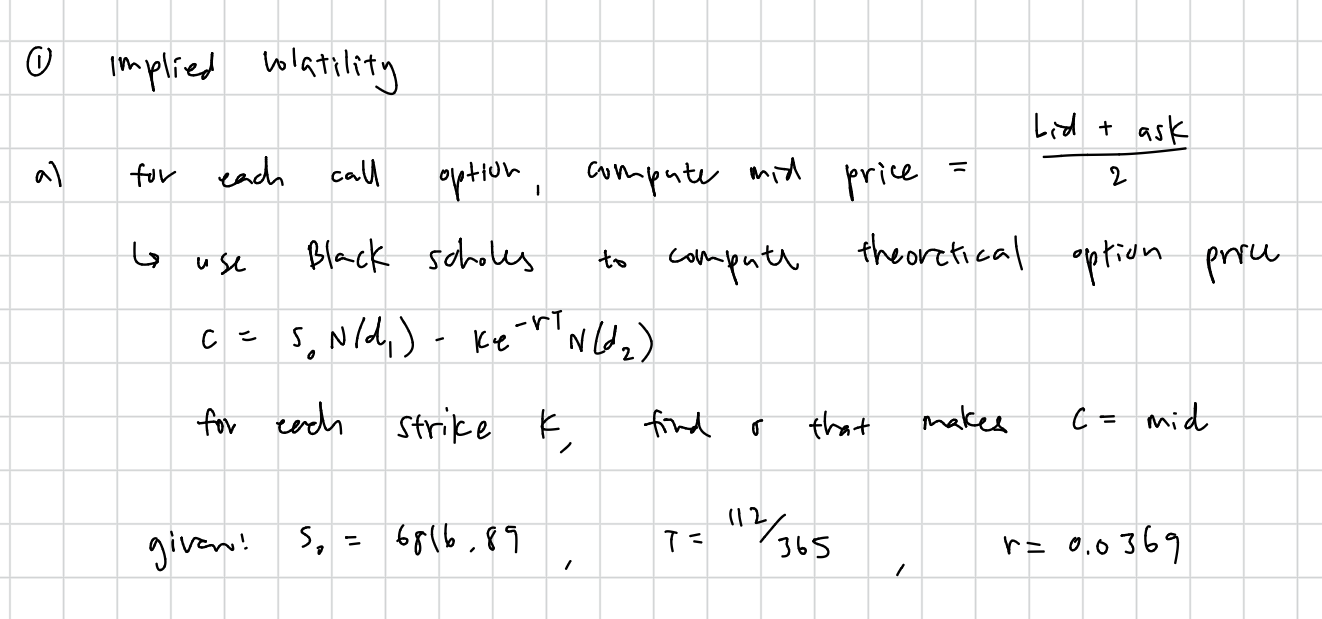

In [7]:
from IPython.display import Image, display 
display(Image("1a.png", width=600)) 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf

S0 = 6816.89
T = 112 / 365
r = 0.0369

def N(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def bs_call(S, K, T, r, sigma):
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S * N(d1) - K * exp(-r * T) * N(d2)

def bs_put(S, K, T, r, sigma):
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return K * exp(-r * T) * N(-d2) - S * N(-d1)

def implied_vol(price, S, K, T, r, option_type, tol=1e-8, max_iter=200):
    low = 1e-8
    high = 5.0
    
    if option_type == "call":
        price_func = bs_call
    elif option_type == "put":
        price_func = bs_put
    else:
        raise ValueError("option_type must be 'call' or 'put'")
    
    for _ in range(max_iter):
        mid = (low + high) / 2
        model_price = price_func(S, K, T, r, mid)
        
        if abs(model_price - price) < tol:
            return mid
        
        if model_price < price:
            low = mid
        else:
            high = mid
    
    return (low + high) / 2

,strike,bid,ask,mid,implied_vol
0,5600.0,1314.3,1322.4,1318.35,0.277693
1,6000.0,948.4,955.8,952.10,0.243880
2,6050.0,904.0,911.3,907.65,0.239627
3,6240.0,739.2,746.1,742.65,0.223555
4,6360.0,638.5,645.1,641.80,0.213005


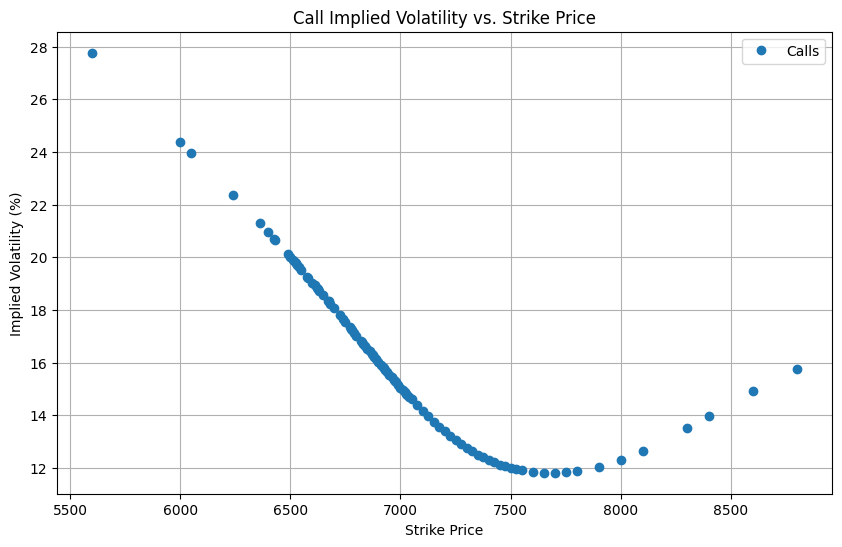

In [4]:
calls = pd.read_csv("PSET5 Calls.csv")

calls["mid"] = (calls["bid"] + calls["ask"]) / 2

calls["implied_vol"] = calls.apply(
    lambda row: implied_vol(
        price=row["mid"],
        S=S0,
        K=row["strike"],
        T=T,
        r=r,
        option_type="call"
    ),
    axis=1
)

display(calls.head())

plt.figure(figsize=(10, 6))
plt.plot(calls["strike"], 100 * calls["implied_vol"], marker="o", linestyle="", label="Calls")

plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility (%)")
plt.title("Call Implied Volatility vs. Strike Price")
plt.legend()
plt.grid(True)
plt.show()

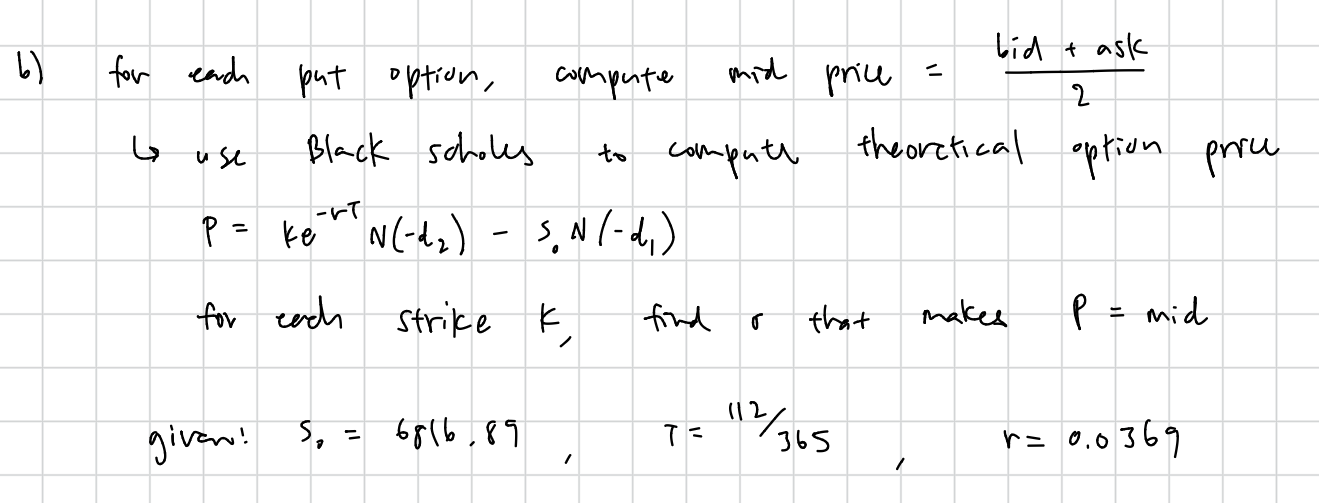

In [8]:
display(Image("1b.png", width=600))

,strike,bid,ask,mid,implied_vol
0,2800.0,3.3,3.9,3.60,0.662188
1,3000.0,4.1,4.5,4.30,0.627904
2,3200.0,4.9,5.5,5.20,0.596595
3,3400.0,5.8,6.5,6.15,0.565319
4,3600.0,6.9,7.6,7.25,0.535289


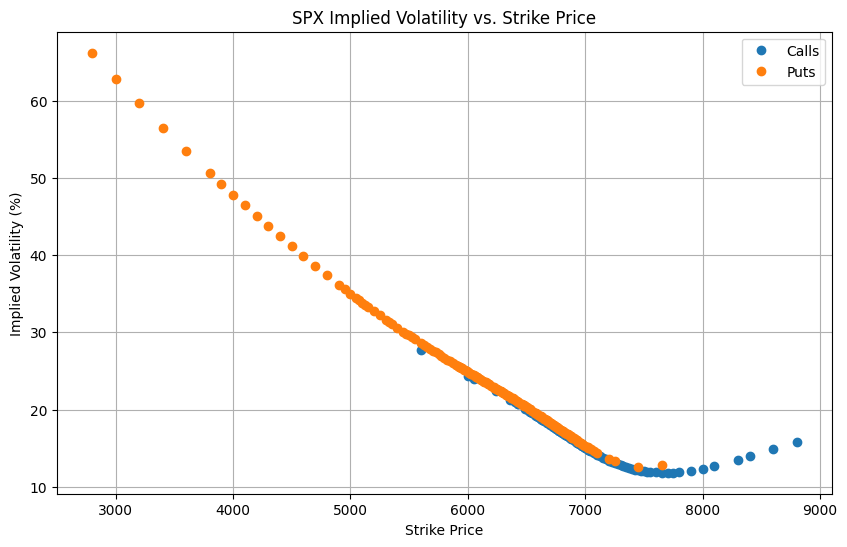

In [9]:
puts = pd.read_csv("PSET5 Puts.csv")

puts["mid"] = (puts["bid"] + puts["ask"]) / 2

puts["implied_vol"] = puts.apply(
    lambda row: implied_vol(
        price=row["mid"],
        S=S0,
        K=row["strike"],
        T=T,
        r=r,
        option_type="put"
    ),
    axis=1
)

display(puts.head())

plt.figure(figsize=(10, 6))

plt.plot(calls["strike"], 100 * calls["implied_vol"], marker="o", linestyle="", label="Calls")
plt.plot(puts["strike"], 100 * puts["implied_vol"], marker="o", linestyle="", label="Puts")

plt.xlabel("Strike Price")
plt.ylabel("Implied Volatility (%)")
plt.title("SPX Implied Volatility vs. Strike Price")
plt.legend()
plt.grid(True)
plt.show()

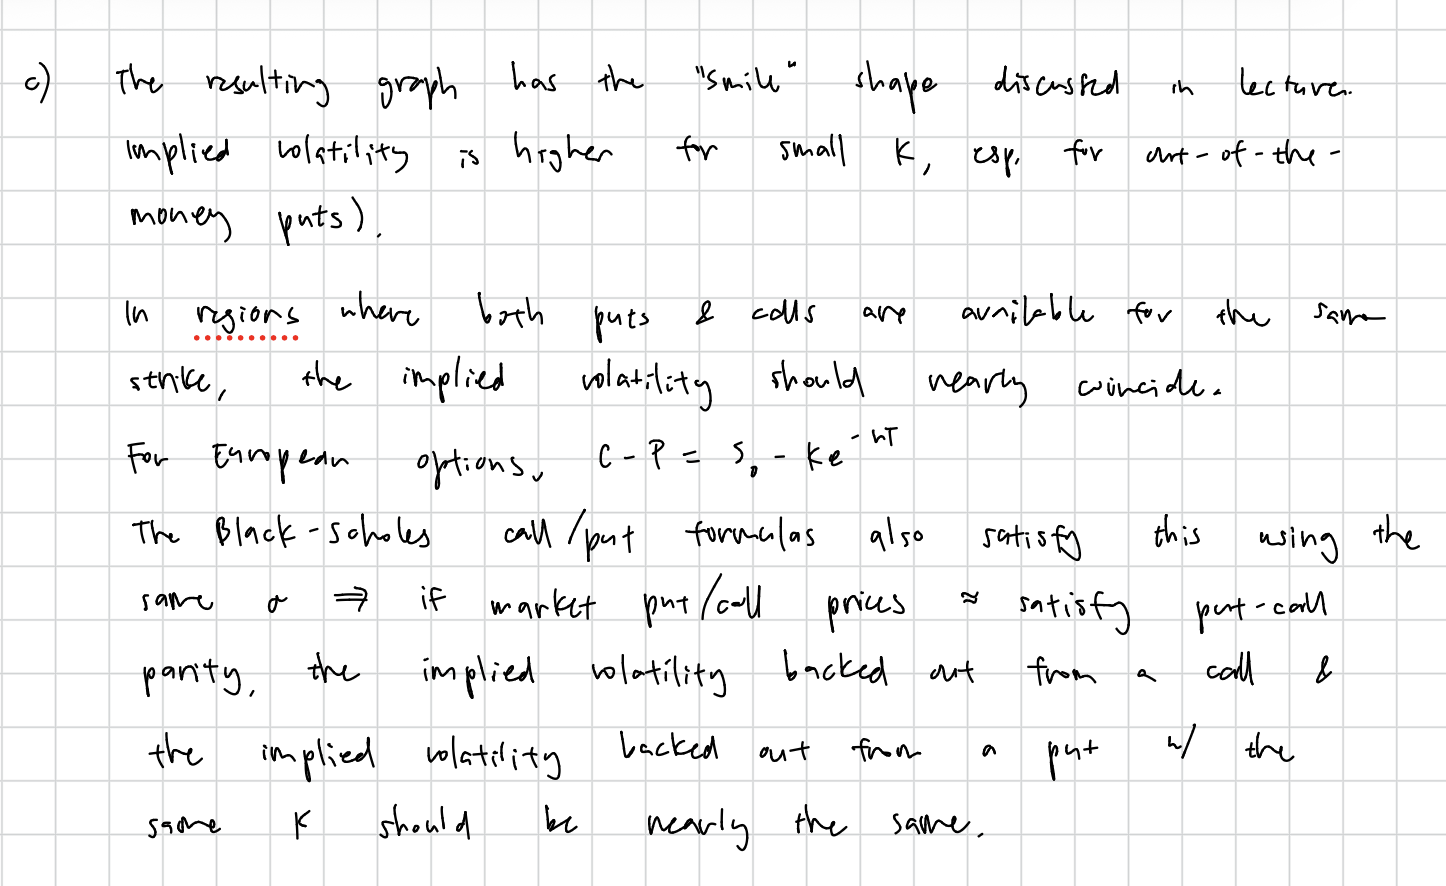

In [10]:
display(Image("1c.png", width=600))

2. delta hedging


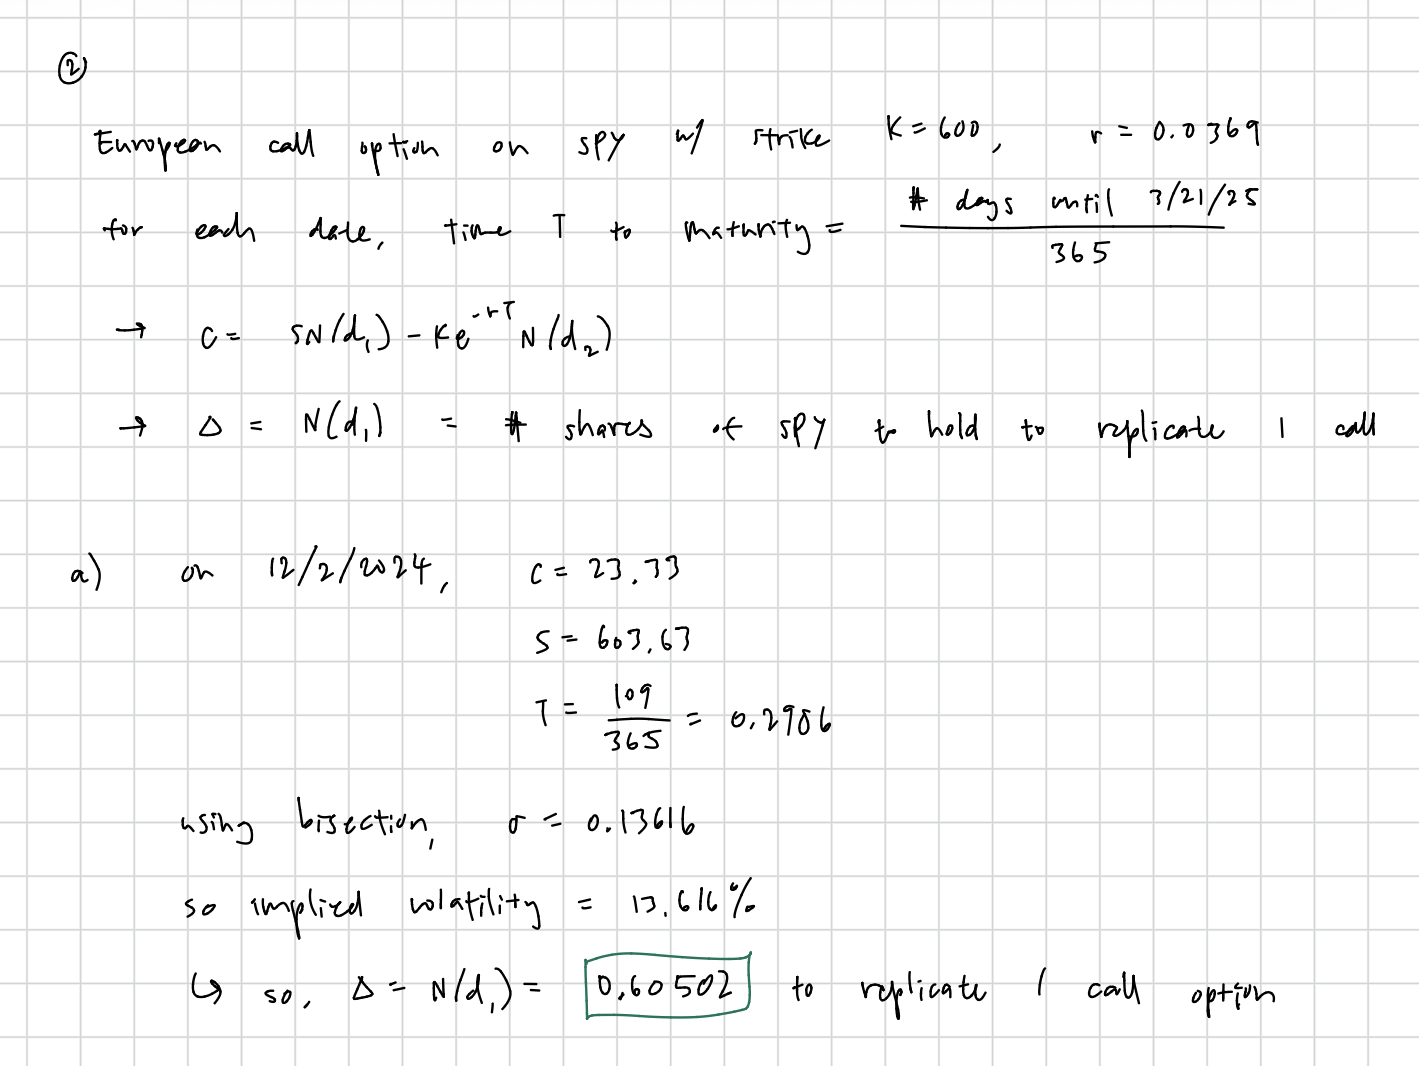

In [12]:
display(Image("2a.png", width=600))

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import log, sqrt, exp, erf

K = 600
r = 0.0369
maturity = pd.Timestamp("2025-03-21")

def N(x):
    return 0.5 * (1 + erf(x / sqrt(2)))

def bs_call(S, K, T, r, sigma):
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    d2 = d1 - sigma * sqrt(T)
    return S * N(d1) - K * exp(-r * T) * N(d2)

def call_delta(S, K, T, r, sigma):
    d1 = (log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrt(T))
    return N(d1)

def implied_vol_call(price, S, K, T, r, tol=1e-8, max_iter=200):
    low = 1e-8
    high = 5.0
    
    for _ in range(max_iter):
        mid = (low + high) / 2
        model_price = bs_call(S, K, T, r, mid)
        
        if abs(model_price - price) < tol:
            return mid
        
        if model_price < price:
            low = mid
        else:
            high = mid
    
    return (low + high) / 2

hedge = pd.read_csv("hedge.csv")
hedge["Date"] = pd.to_datetime(hedge["Date"], format="%m/%d/%Y")

# First day: December 2, 2024
S0 = hedge.loc[0, "spot"]
C0 = hedge.loc[0, "option_price"]
date0 = hedge.loc[0, "Date"]

T0 = (maturity - date0).days / 365

sigma0 = implied_vol_call(C0, S0, K, T0, r)
delta0 = call_delta(S0, K, T0, r, sigma0)

print("Part (a)")
print(f"Date: {date0.date()}")
print(f"SPY price: {S0:.2f}")
print(f"Option price: {C0:.2f}")
print(f"T: {T0:.6f}")
print(f"Implied volatility: {sigma0:.6f}")
print(f"Implied volatility (%): {100 * sigma0:.2f}%")
print(f"Delta: {delta0:.6f}")
print(f"Shares of SPY to hold: {delta0:.6f}")

Part (a)
Date: 2024-12-02
SPY price: 603.63
Option price: 23.33
T: 0.298630
Implied volatility: 0.136163
Implied volatility (%): 13.62%
Delta: 0.605019
Shares of SPY to hold: 0.605019


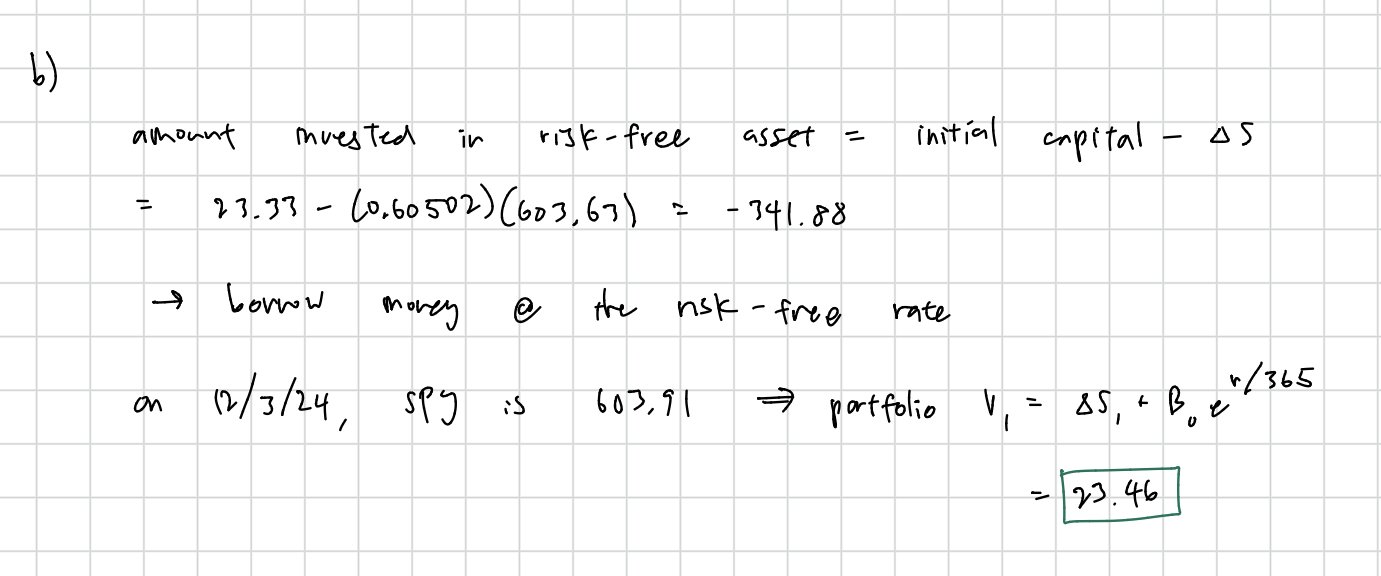

In [15]:
display(Image("2b.png", width=600))

In [16]:
# Initial cash position after buying delta shares
cash0 = C0 - delta0 * S0

# Next day: December 3, 2024
S1 = hedge.loc[1, "spot"]
date1 = hedge.loc[1, "Date"]

dt = (date1 - date0).days / 365

portfolio_value_dec3 = delta0 * S1 + cash0 * exp(r * dt)

print("Part (b)")
print(f"Initial cash position: {cash0:.6f}")
print(f"SPY price on Dec 3: {S1:.2f}")
print(f"Portfolio value on Dec 3: {portfolio_value_dec3:.6f}")
print(f"Market option price on Dec 3: {hedge.loc[1, 'option_price']:.6f}")

Part (b)
Initial cash position: -341.877459
SPY price on Dec 3: 603.91
Portfolio value on Dec 3: 23.464841
Market option price on Dec 3: 23.400000


c)

,Date,spot,option_price,implied_vol,delta,portfolio_value,cash_position
0,2024-12-02,603.63,23.33,0.136163,0.605019,23.330000,-341.877459
1,2024-12-03,603.91,23.40,0.136277,0.607180,23.464841,-343.217415
2,2024-12-04,607.66,25.80,0.137723,0.637759,25.707068,-361.833501
3,2024-12-05,606.66,25.13,0.138368,0.628936,25.032727,-356.517614
4,2024-12-06,607.81,25.86,0.139335,0.637753,25.719959,-361.912994


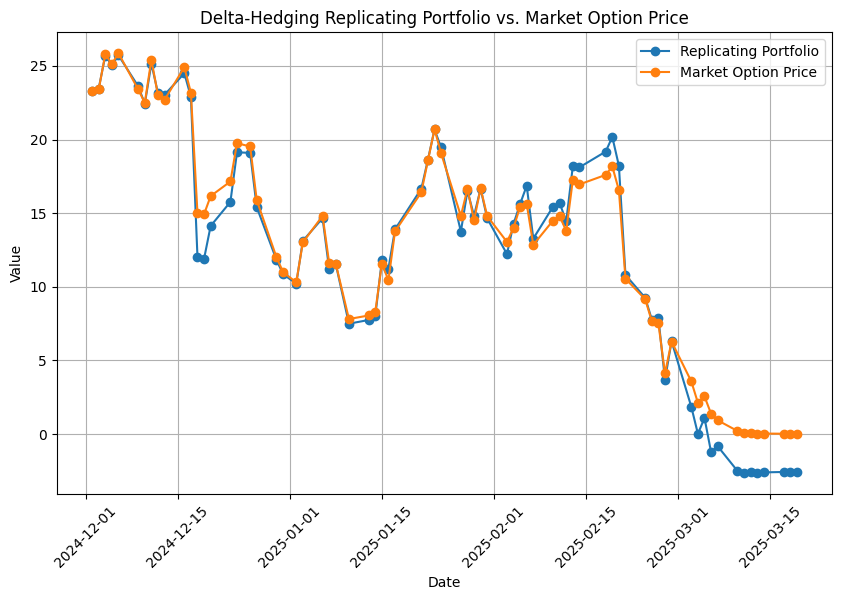

In [19]:
portfolio_values = []
implied_vols = []
deltas = []
cash_positions = []

# Initialize on the first day
current_date = hedge.loc[0, "Date"]
S = hedge.loc[0, "spot"]
option_price = hedge.loc[0, "option_price"]
T = (maturity - current_date).days / 365

sigma = implied_vol_call(option_price, S, K, T, r)
delta = call_delta(S, K, T, r, sigma)

portfolio_value = option_price
cash = portfolio_value - delta * S

portfolio_values.append(portfolio_value)
implied_vols.append(sigma)
deltas.append(delta)
cash_positions.append(cash)

# Move through each subsequent trading day
for i in range(1, len(hedge)):
    previous_date = hedge.loc[i - 1, "Date"]
    current_date = hedge.loc[i, "Date"]
    
    S = hedge.loc[i, "spot"]
    option_price = hedge.loc[i, "option_price"]
    
    # Carry cash forward at the risk-free rate
    dt = (current_date - previous_date).days / 365
    cash = cash * exp(r * dt)
    
    # Portfolio value before rebalancing
    portfolio_value = delta * S + cash
    
    # Recompute implied volatility and delta using today's option price
    T = (maturity - current_date).days / 365
    sigma = implied_vol_call(option_price, S, K, T, r)
    new_delta = call_delta(S, K, T, r, sigma)
    
    # Rebalance: total portfolio value stays the same
    cash = portfolio_value - new_delta * S
    delta = new_delta
    
    portfolio_values.append(portfolio_value)
    implied_vols.append(sigma)
    deltas.append(delta)
    cash_positions.append(cash)

hedge["implied_vol"] = implied_vols
hedge["delta"] = deltas
hedge["portfolio_value"] = portfolio_values
hedge["cash_position"] = cash_positions

display(hedge.head())

plt.figure(figsize=(10, 6))

plt.plot(
    hedge["Date"],
    hedge["portfolio_value"],
    marker="o",
    label="Replicating Portfolio"
)

plt.plot(
    hedge["Date"],
    hedge["option_price"],
    marker="o",
    label="Market Option Price"
)

plt.xlabel("Date")
plt.ylabel("Value")
plt.title("Delta-Hedging Replicating Portfolio vs. Market Option Price")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

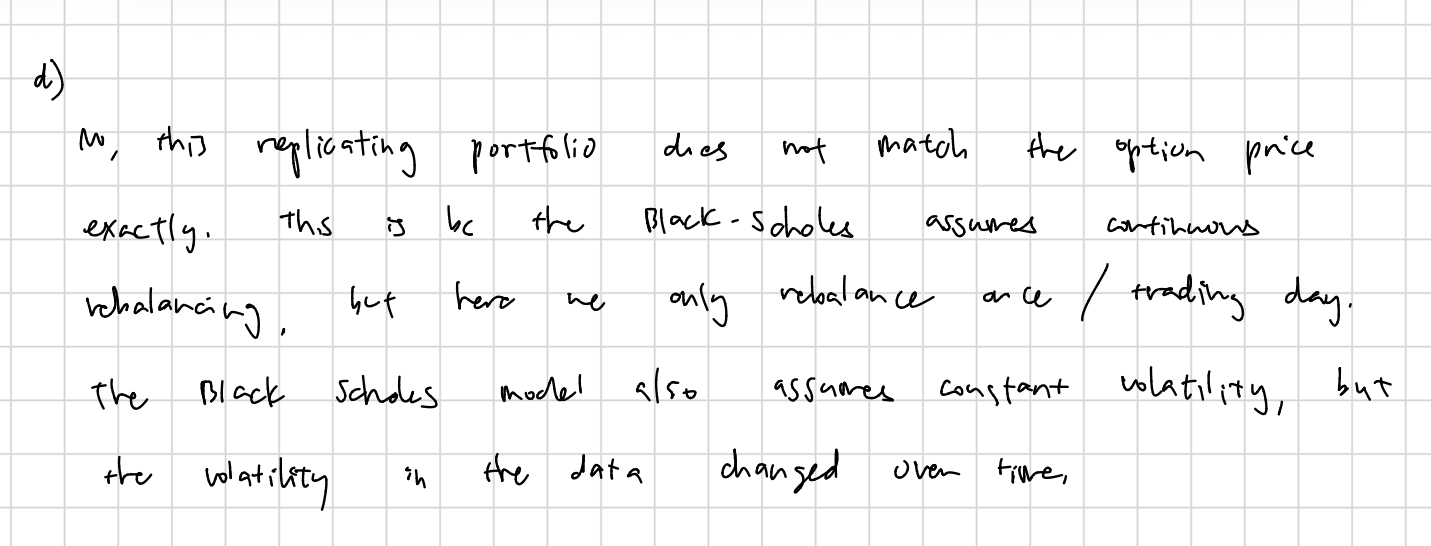

In [20]:
display(Image("2d.png", width=600))

3. markowitz portfolio analysis

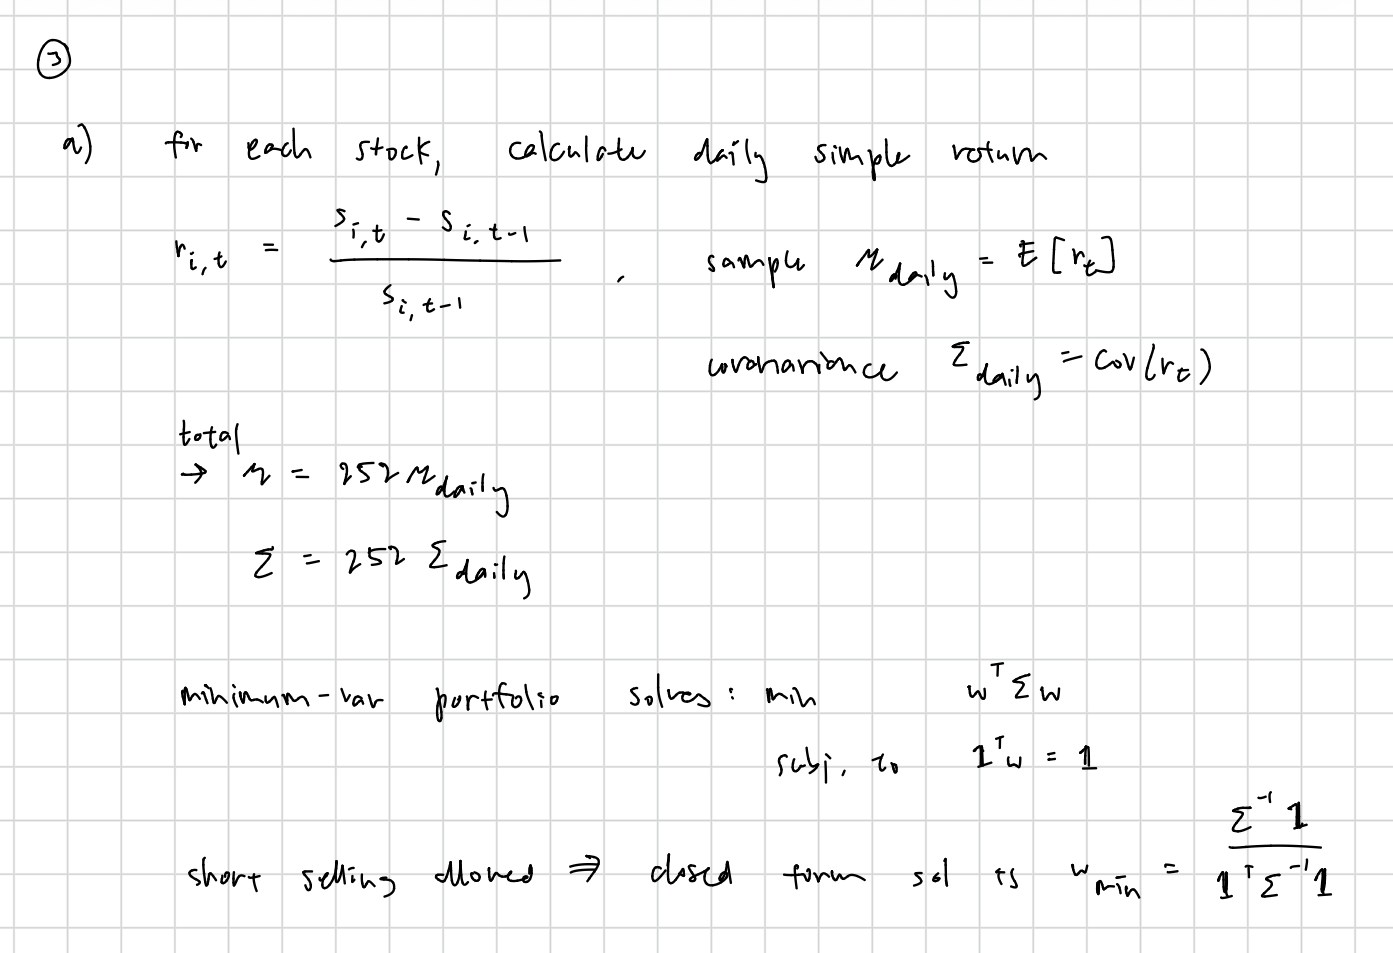

In [22]:
display(Image("3a.png", width=600))

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Change this filename if your file is named techprices.csv
prices = pd.read_csv("PSET5 Tech Prices.csv")

prices["Date"] = pd.to_datetime(prices["Date"])

tickers = list(prices.columns[1:])
n = len(tickers)

# Daily simple returns
returns = prices[tickers].pct_change().dropna()

# Daily mean and covariance
mu_daily = returns.mean()
Sigma_daily = returns.cov()

# Annualized mean and covariance
mu = 252 * mu_daily
Sigma = 252 * Sigma_daily

mu_vec = mu.values
Sigma_mat = Sigma.values
ones = np.ones(n)

# Part (a): minimum-variance portfolio

# w_min = Sigma^{-1} 1 / (1^T Sigma^{-1} 1)
x = np.linalg.solve(Sigma_mat, ones)
w_min = x / (ones @ x)

minvar_return = mu_vec @ w_min
minvar_std = np.sqrt(w_min @ Sigma_mat @ w_min)

minvar_weights = pd.DataFrame({
    "ticker": tickers,
    "weight": w_min
})

print("Part (a): Minimum-variance portfolio")
print(f"Annualized mean return: {minvar_return:.6f}")
print(f"Annualized standard deviation: {minvar_std:.6f}")

display(minvar_weights)

Part (a): Minimum-variance portfolio
Annualized mean return: 0.105659
Annualized standard deviation: 0.138138


,ticker,weight
0,AAPL,0.058189
1,ACN,-0.038993
2,ADBE,-0.028904
3,ADI,0.048836
4,ADSK,-0.055766
...,...,...
62,UI,-0.016910
63,VRSN,0.077568
64,WDAY,0.007124
65,WDC,-0.027506


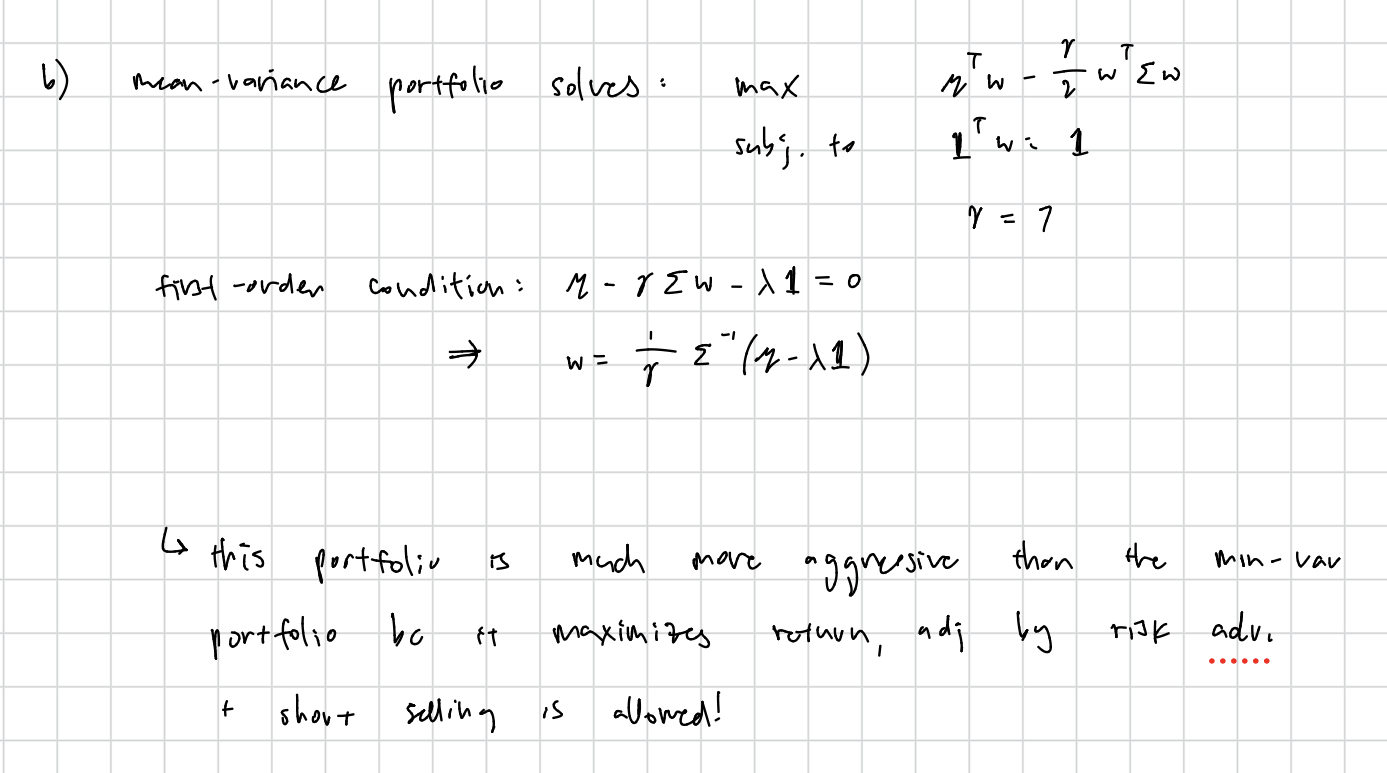

In [23]:
display(Image("3b.png", width=600))

Part (b): Mean-variance portfolio
Annualized mean return: 1.072596
Annualized standard deviation: 0.396505


,ticker,weight
0,AAPL,0.108095
1,ACN,0.321549
2,ADBE,0.143241
3,ADI,-0.312576
4,ADSK,-0.091255
...,...,...
62,UI,0.155228
63,VRSN,-0.020929
64,WDAY,-0.228867
65,WDC,-0.318927


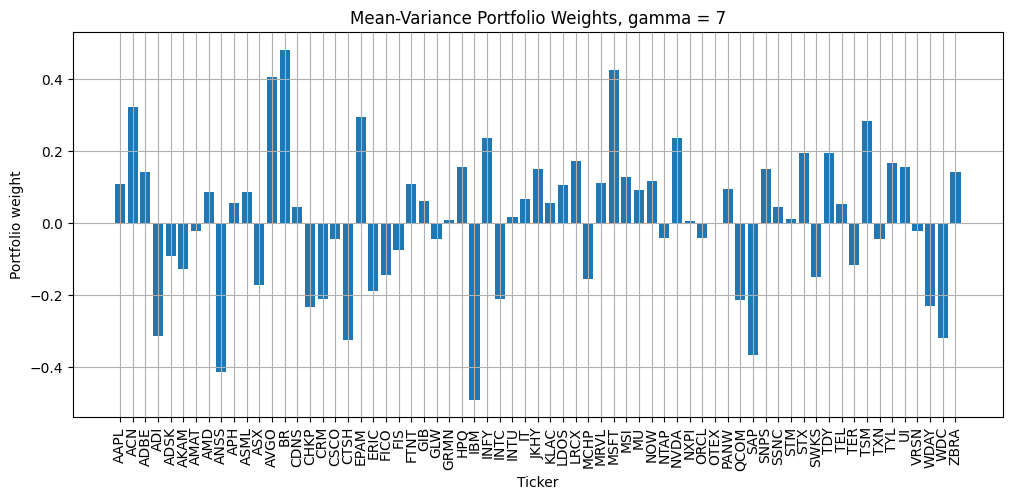

In [ ]:
gamma = 7

# Solve for Sigma^{-1} mu and Sigma^{-1} 1
y = np.linalg.solve(Sigma_mat, mu_vec)
x = np.linalg.solve(Sigma_mat, ones)

A = ones @ x
B = ones @ y

# Lagrange multiplier from budget constraint
lam = (B - gamma) / A

# Mean-variance weights
w_mv = (y - lam * x) / gamma

mv_return = mu_vec @ w_mv
mv_std = np.sqrt(w_mv @ Sigma_mat @ w_mv)

mv_weights = pd.DataFrame({
    "ticker": tickers,
    "weight": w_mv
})

print("Part (b): Mean-variance portfolio")
print(f"Annualized mean return: {mv_return:.6f}")
print(f"Annualized standard deviation: {mv_std:.6f}")

display(mv_weights)

plt.figure(figsize=(12, 5))
plt.bar(mv_weights["ticker"], mv_weights["weight"])
plt.xlabel("Ticker")
plt.ylabel("Portfolio weight")
plt.title("Mean-Variance Portfolio Weights, gamma = 7")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

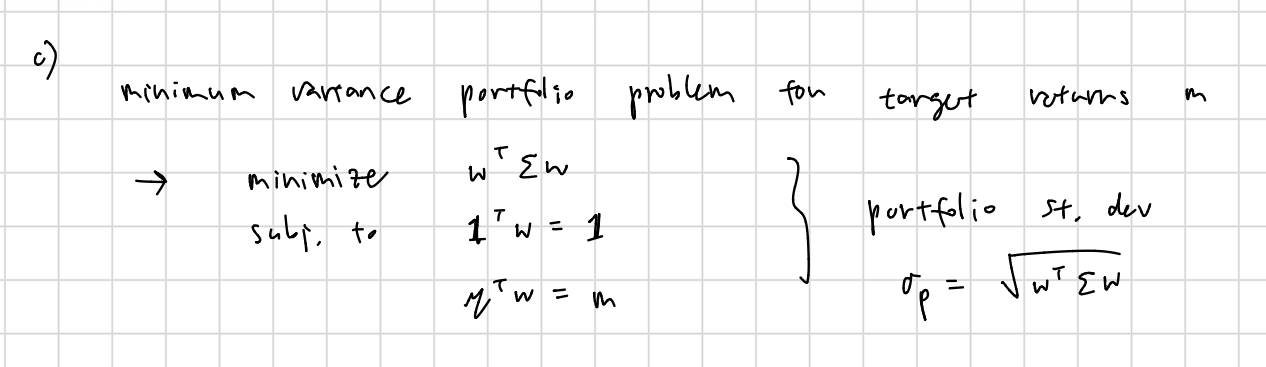

In [25]:
display(Image("3c.png", width=600))

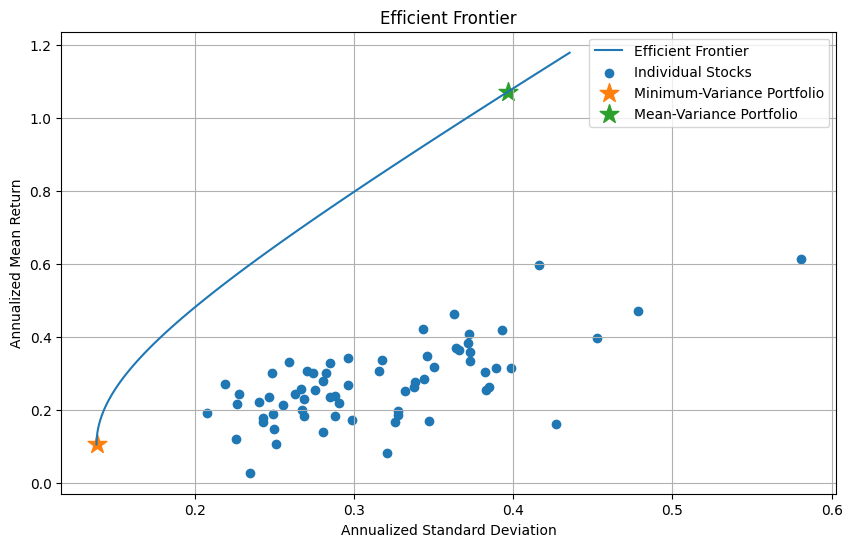

In [27]:
A = ones @ np.linalg.solve(Sigma_mat, ones)
B = ones @ np.linalg.solve(Sigma_mat, mu_vec)
C = mu_vec @ np.linalg.solve(Sigma_mat, mu_vec)
D = A * C - B**2

target_returns = np.linspace(
    minvar_return,
    max(mu.max(), mv_return) * 1.1,
    100
)

frontier_stds = []
frontier_returns = []

for target in target_returns:
    coeff_1 = (C - B * target) / D
    coeff_2 = (A * target - B) / D
    
    w_target = np.linalg.solve(
        Sigma_mat,
        coeff_1 * ones + coeff_2 * mu_vec
    )
    
    port_return = mu_vec @ w_target
    port_std = np.sqrt(w_target @ Sigma_mat @ w_target)
    
    frontier_returns.append(port_return)
    frontier_stds.append(port_std)

# Individual stock points
stock_stds = np.sqrt(np.diag(Sigma_mat))
stock_returns = mu_vec

plt.figure(figsize=(10, 6))

plt.plot(frontier_stds, frontier_returns, label="Efficient Frontier")

plt.scatter(stock_stds, stock_returns, label="Individual Stocks")

plt.scatter(
    minvar_std,
    minvar_return,
    marker="*",
    s=200,
    label="Minimum-Variance Portfolio"
)

plt.scatter(
    mv_std,
    mv_return,
    marker="*",
    s=200,
    label="Mean-Variance Portfolio"
)

plt.xlabel("Annualized Standard Deviation")
plt.ylabel("Annualized Mean Return")
plt.title("Efficient Frontier")
plt.legend()
plt.grid(True)
plt.show()

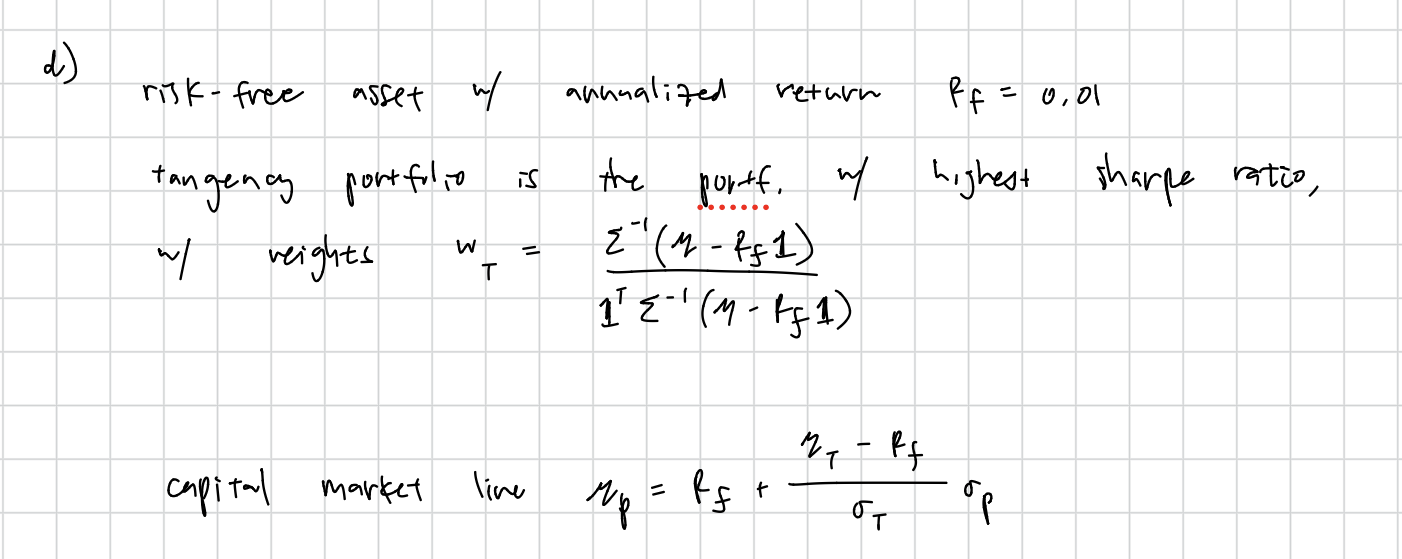

In [28]:
display(Image("3d.png", width=600))

Part (d): Tangency portfolio
Annualized mean return: 1.455850
Annualized standard deviation: 0.537046
Sharpe ratio: 2.692230


,ticker,weight
0,AAPL,0.127876
1,ACN,0.464453
2,ADBE,0.211473
3,ADI,-0.455824
4,ADSK,-0.105321
...,...,...
62,UI,0.223457
63,VRSN,-0.059968
64,WDAY,-0.322404
65,WDC,-0.434434


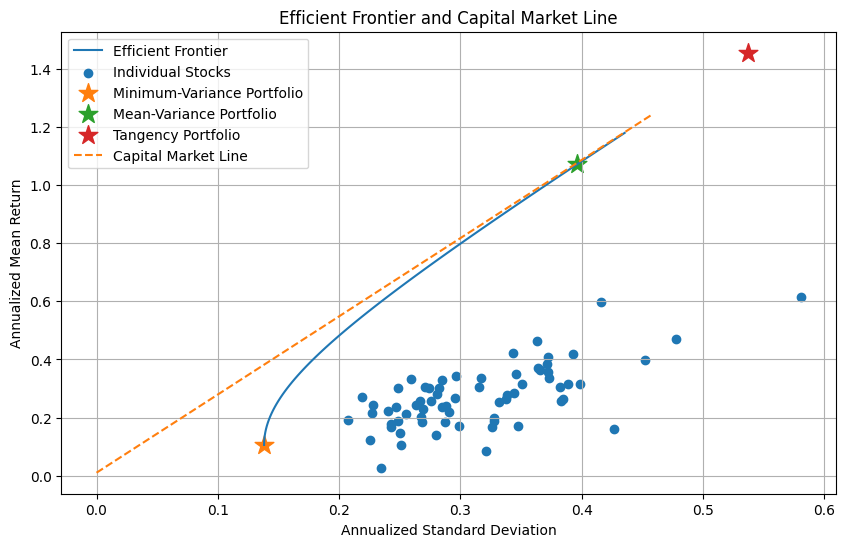

In [29]:
Rf = 0.01

excess_mu = mu_vec - Rf * ones

z = np.linalg.solve(Sigma_mat, excess_mu)
w_tan = z / (ones @ z)

tan_return = mu_vec @ w_tan
tan_std = np.sqrt(w_tan @ Sigma_mat @ w_tan)
tan_sharpe = (tan_return - Rf) / tan_std

tan_weights = pd.DataFrame({
    "ticker": tickers,
    "weight": w_tan
})

print("Part (d): Tangency portfolio")
print(f"Annualized mean return: {tan_return:.6f}")
print(f"Annualized standard deviation: {tan_std:.6f}")
print(f"Sharpe ratio: {tan_sharpe:.6f}")

display(tan_weights)

# Capital market line
cml_stds = np.linspace(0, max(frontier_stds) * 1.05, 100)
cml_returns = Rf + tan_sharpe * cml_stds

plt.figure(figsize=(10, 6))

plt.plot(frontier_stds, frontier_returns, label="Efficient Frontier")
plt.scatter(stock_stds, stock_returns, label="Individual Stocks")

plt.scatter(
    minvar_std,
    minvar_return,
    marker="*",
    s=200,
    label="Minimum-Variance Portfolio"
)

plt.scatter(
    mv_std,
    mv_return,
    marker="*",
    s=200,
    label="Mean-Variance Portfolio"
)

plt.scatter(
    tan_std,
    tan_return,
    marker="*",
    s=200,
    label="Tangency Portfolio"
)

plt.plot(cml_stds, cml_returns, linestyle="--", label="Capital Market Line")

plt.xlabel("Annualized Standard Deviation")
plt.ylabel("Annualized Mean Return")
plt.title("Efficient Frontier and Capital Market Line")
plt.legend()
plt.grid(True)
plt.show()

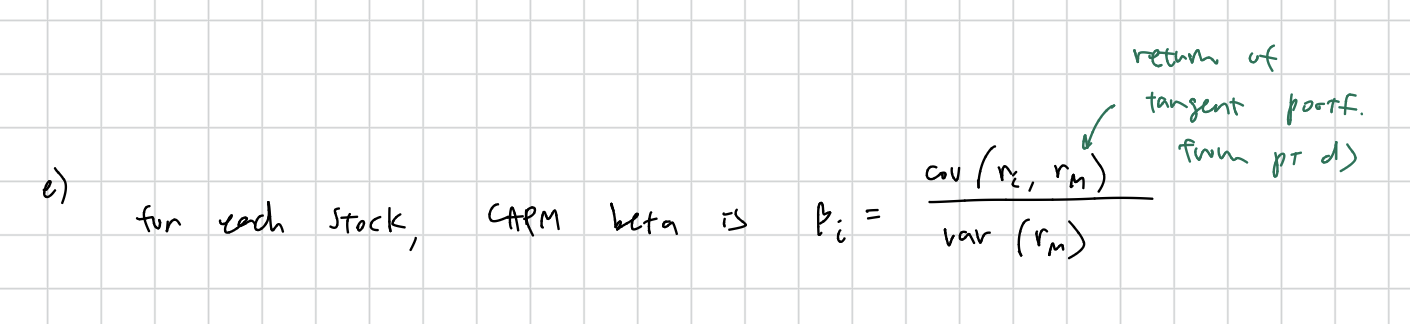

In [30]:
display(Image("3e.png", width=600))

In [32]:
market_returns = returns.values @ w_tan

betas = {}

for j, ticker in enumerate(tickers):
    stock_returns_j = returns.iloc[:, j].values
    
    cov_im = np.cov(stock_returns_j, market_returns, ddof=1)[0, 1]
    var_m = np.var(market_returns, ddof=1)
    
    betas[ticker] = cov_im / var_m

beta_series = pd.Series(betas).sort_index()

print("First five ticker-beta pairs:")
display(beta_series.head(5))

print("Last five ticker-beta pairs:")
display(beta_series.tail(5))

First five ticker-beta pairs:


AAPL    0.201421
ACN     0.161923
ADBE    0.230665
ADI     0.145135
ADSK    0.190252
dtype: float64

Last five ticker-beta pairs:


UI      0.318949
VRSN    0.156395
WDAY    0.170000
WDC     0.103977
ZBRA    0.245606
dtype: float64

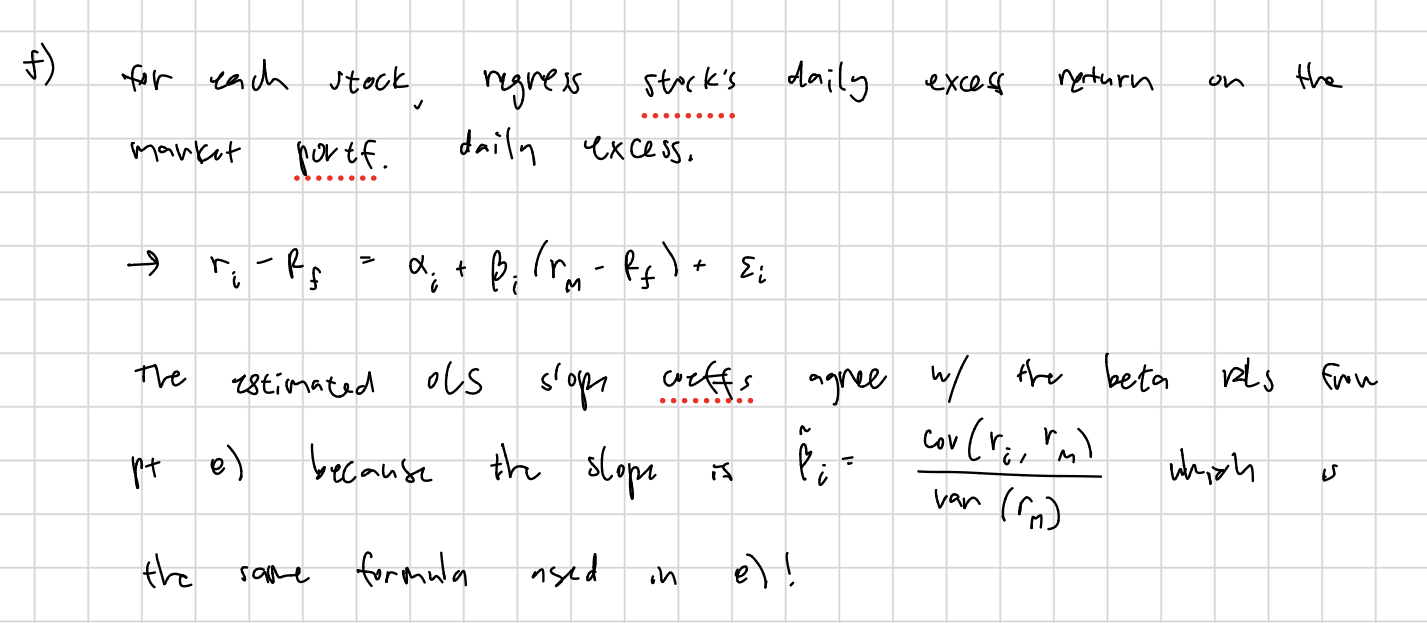

In [33]:
display(Image("3f.png", width=600))

In [35]:
Rf_daily = Rf / 252

market_excess = market_returns - Rf_daily

ols_betas = {}
ols_alphas = {}

# Regression matrix with intercept
X = np.column_stack([
    np.ones(len(market_excess)),
    market_excess
])

for j, ticker in enumerate(tickers):
    stock_excess = returns.iloc[:, j].values - Rf_daily
    
    alpha_hat, beta_hat = np.linalg.lstsq(X, stock_excess, rcond=None)[0]
    
    ols_alphas[ticker] = alpha_hat
    ols_betas[ticker] = beta_hat

ols_beta_series = pd.Series(ols_betas).sort_index()

comparison = pd.DataFrame({
    "CAPM beta": beta_series,
    "OLS beta": ols_beta_series,
    "difference": ols_beta_series - beta_series
})

display(comparison)

print("Maximum absolute difference:")
print(comparison["difference"].abs().max())

,CAPM beta,OLS beta,difference
AAPL,0.201421,0.201421,5.551115e-17
ACN,0.161923,0.161923,8.326673e-17
ADBE,0.230665,0.230665,1.110223e-16
ADI,0.145135,0.145135,1.665335e-16
ADSK,0.190252,0.190252,0.000000e+00
...,...,...,...
UI,0.318949,0.318949,2.220446e-16
VRSN,0.156395,0.156395,2.775558e-17
WDAY,0.170000,0.170000,8.326673e-17
WDC,0.103977,0.103977,9.714451e-17


Maximum absolute difference:
2.7755575615628914e-16
